In [1]:
from os.path import join
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import lstsq
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from statistical_tests import fisher_mean
from ctf_dataset.load import create_wrapped_dataset
from behavior_heuristics import has_opponent_flag
from coupling_metrics import behavior_regression, behavior_encoding, nested_encoding

In [2]:
base_dir = '/jukebox/hasson/snastase/social-ctf'
data_dir = join(base_dir, 'data_v1')
wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual_v3.hdf5")

sns.set(context='notebook', style='white')
palette = sns.color_palette(['.65', 'darkgoldenrod'])

In [3]:
action_labels = {'look left/right': [0., 1., 2., 3., 4.],
                 'look up/down': [0., 1., 2.],
                 'strafe left/right': [0., 1., 2.],
                 'move backward/forward': [0., 1., 2.],
                 'fire or switch': [0., 1., 2., 3.],
                 'jump': [0., 1.]}

n_subactions = len(np.concatenate(list(action_labels.values())))
assert n_subactions == 20

# Function for expanding 6 action channels into 20 subactions
def expand_actions(actions, action_labels):
    
    subactions = {}
    for a, label in enumerate(action_labels):
        
        # Expand look left/right into five separate actions
        subactions[label] = np.zeros((actions.shape[:-1] +
                                      (len(action_labels[label]),)))
        for subaction in action_labels[label]:
            subactions[label][..., int(subaction)][
                actions[..., a] == subaction] = 1
        
        # Check that each subaction occurs uniquely in time
        #assert np.all(np.sum(subactions[label], axis=1) == 1)
        
    subactions = np.concatenate([subactions[a] for a in subactions],
                                axis=-1)
    #assert np.array_equal(np.unique(b), np.array([0, 1]))
            
    return subactions

In [4]:
def stack_behaviors(player_id, map_id=slice(None), 
                    matchup_id=0, repeat_id=slice(None)):
    
    
    # health: 1 value
    # position: 2 x, y values
    # direction: 4 sin/cos values (from 2 angles)
    # velocity: 2 x, y values
    # has flag: 1 value
    # actions: 20 one-hot values (from 6 actions)
    # total: 30 behavior variables

    behav_labels = ['health', 'position', 'direction', 'velocity']

    player_behav = []

    # Loop through simple behaviors/relations
    for behav_label in behav_labels:
        behav = wrap_f[f'map/matchup/repeat/player/time/{behav_label}'][
            map_id, matchup_id, repeat_id, player_id][..., :2]

        if behav_label == 'direction':
            behav = np.concatenate((np.sin(np.radians(behav)),
                                    np.cos(np.radians(behav))),
                                   axis=-1)

        player_behav.append(behav)

    # Extract whether has opponent flag  
    has_flag = has_opponent_flag(wrap_f, map_id=map_id, matchup_id=matchup_id,
                                 repeat_id=repeat_id, player_id=player_id,
                                 min_behavior_length=0)
    player_behav.append(has_flag)

    # Extract action outputs
    actions = wrap_f[f'map/matchup/repeat/player/time/action'][
                     map_id, matchup_id, repeat_id, player_id]
    actions_1hot = expand_actions(actions, action_labels)
    player_behav.append(actions_1hot)

    return np.concatenate(player_behav, axis=-1)

In [5]:
behav_labels = (['health'] + ['position'] * 2 +
                ['direction'] * 4 + ['velocity'] * 2 +
                ['has flag'] +
                ['look left/right'] * 5 +
                ['look up/down'] * 3 +
                ['strafe left/right'] * 3 +
                ['move backward/forward'] * 3 +
                ['fire or switch'] * 4 +
                ['jump'] * 2)
assert len(behav_labels) == 30

In [6]:
def apply_lag(train_samples, test_samples,
              train_targets, test_targets,
              lag=None):
    
    if not lag or lag == 0:
        train_samples_lag = train_samples
        train_targets_lag = train_targets
        test_samples_lag = test_samples
        test_targets_lag = test_targets

    elif lag > 0:
        train_samples_lag = train_samples[..., :-lag, :]
        train_targets_lag = train_targets[..., lag:, :]
        test_samples_lag = test_samples[..., :-lag, :]
        test_targets_lag = test_targets[..., lag:, :]

    elif lag < 0:
        train_samples_lag = train_samples[..., -lag:, :]
        train_targets_lag = train_targets[..., :lag, :]
        test_samples_lag = test_samples[..., -lag:, :]
        test_targets_lag = test_targets[..., :lag, :]
        
    return (train_samples_lag, test_samples_lag,
            train_targets_lag, test_targets_lag)

In [7]:
# Load up and stack behaviors for player, teammate, and opponent
n_players = 4
map_id, matchup_id, repeat_id = slice(None), 0, 0

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

stack_behav = []
for player_id in np.arange(n_players):
    player_behav = stack_behaviors(
        player_id, map_id=map_id,
        matchup_id=matchup_id, repeat_id=repeat_id)
    print(f"Player behavior shape: {player_behav.shape}")
    
    teammate_behav = stack_behaviors(
        player_teammate[player_id], map_id=map_id,
        matchup_id=matchup_id, repeat_id=repeat_id)
    print(f"Teammate behavior shape: {teammate_behav.shape}")

    opponent_behav = []
    for opp_id in player_opponents[player_id]:
        opponent_behav.append(stack_behaviors(
            opp_id, map_id=map_id,
            matchup_id=matchup_id, repeat_id=repeat_id))
    opponent_behav = np.concatenate(opponent_behav, axis=-1)
    print(f"Opponent behavior shape: {opponent_behav.shape}")
    
    stack_behav.append(np.concatenate((player_behav,
                                       teammate_behav,
                                       opponent_behav), axis=-1))

stack_behav = np.stack(stack_behav, -3)
print(f"Stacked behavior shape: {stack_behav.shape}")

Player behavior shape: (32, 4501, 30)
Teammate behavior shape: (32, 4501, 30)
Opponent behavior shape: (32, 4501, 60)
Player behavior shape: (32, 4501, 30)
Teammate behavior shape: (32, 4501, 30)
Opponent behavior shape: (32, 4501, 60)
Player behavior shape: (32, 4501, 30)
Teammate behavior shape: (32, 4501, 30)
Opponent behavior shape: (32, 4501, 60)
Player behavior shape: (32, 4501, 30)
Teammate behavior shape: (32, 4501, 30)
Opponent behavior shape: (32, 4501, 60)
Stacked behavior shape: (32, 4, 4501, 120)


In [ ]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_width, teammate_width, opponent_width = 30, 30, 60

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'joint score': [], 'nested score': [],
              'teammate score': [], 'opponent score': [],
              'lag': [], 'test map': [], 'behavior': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    for player_id in np.arange(n_players):
        for lag in lags.keys():

            train_behav = stack_behav[train_maps, player_id, :, player_width:]
            test_behav = stack_behav[test_map, player_id, :, player_width:]
            train_targets = stack_behav[train_maps, player_id, :, :player_width]
            test_targets = stack_behav[test_map, player_id, :, :player_width]
           
            (train_behav, test_behav,
             train_targets, test_targets) = apply_lag(train_behav, test_behav,
                                                      train_targets, test_targets,
                                                      lag=lag)
            
            train_behav = train_behav.reshape((-1, train_behav.shape[-1]))
            test_behav = test_behav.reshape((-1, test_behav.shape[-1]))
            train_targets = train_targets.reshape((-1, train_targets.shape[-1]))
            test_targets = test_targets.reshape((-1, test_targets.shape[-1]))
            
            scores = behavior_regression(train_behav, test_behav,
                                         train_targets, test_targets,
                                         teammate_width=teammate_width,
                                         opponent_width=opponent_width,
                                         scorer=pearsonr)
            (joint_scores, nested_scores,
             teammate_scores, opponent_scores) = scores
            lag_scores['joint score'].extend(joint_scores)
            lag_scores['nested score'].extend(nested_scores)
            lag_scores['teammate score'].extend(teammate_scores)
            lag_scores['opponent score'].extend(opponent_scores)
            lag_scores['lag'].extend([lags[lag]] * teammate_width)
            lag_scores['test map'].extend([test_map] * teammate_width)
            lag_scores['behavior'].extend(behav_labels)
            lag_scores['player'].extend([player_id] * teammate_width)
            for l, ss in zip(['joint', 'player', 'teammate', 'opponent'],
                          [joint_scores, nested_scores,
                           teammate_scores, opponent_scores]):
                print(f"player {player_id} lag {lag} "
                      f"{l} r = {[f'{s:.2f}' for s in ss[:8]]} "
                      f"(test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/behav-reg-r_opp-both_matchup-{matchup_id}_results.csv', index=False)

player 0 lag 150 joint r = ['-0.24', '0.07', '0.13', '0.05', '0.07', '0.75', '0.75', '-0.01'] (test map 0)
player 0 lag 150 player r = ['-0.10', '0.05', '0.19', '0.05', '0.06', '0.73', '0.73', '-0.04'] (test map 0)
player 0 lag 150 teammate r = ['-0.27', '0.04', '0.02', '0.03', '0.05', '0.67', '0.67', '0.04'] (test map 0)
player 0 lag 150 opponent r = ['-0.10', '0.05', '0.18', '0.05', '0.06', '0.73', '0.73', '-0.04'] (test map 0)
player 0 lag 75 joint r = ['-0.10', '0.06', '0.16', '0.02', '0.02', '0.74', '0.75', '0.03'] (test map 0)
player 0 lag 75 player r = ['0.01', '-0.04', '-0.01', '0.03', '0.03', '0.72', '0.72', '0.03'] (test map 0)
player 0 lag 75 teammate r = ['-0.13', '0.07', '0.17', '0.00', '-0.01', '0.67', '0.67', '0.00'] (test map 0)
player 0 lag 75 opponent r = ['-0.01', '-0.02', '-0.02', '0.03', '0.03', '0.72', '0.72', '0.04'] (test map 0)
player 0 lag 15 joint r = ['0.02', '0.12', '0.42', '0.10', '0.10', '0.75', '0.75', '0.06'] (test map 0)
player 0 lag 15 player r = ['-0

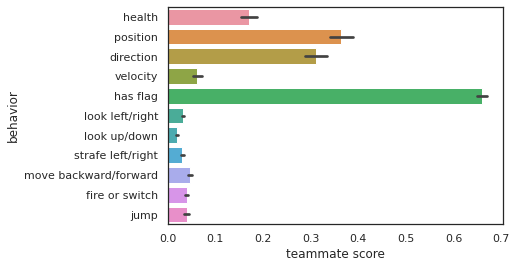

In [8]:
scores_df = pd.read_csv(f'results/behav-reg-r_opp-both_matchup-{matchup_id}_results.csv')
sns.barplot(y='behavior', x='teammate score', data=scores_df[scores_df['lag'] == 0]);

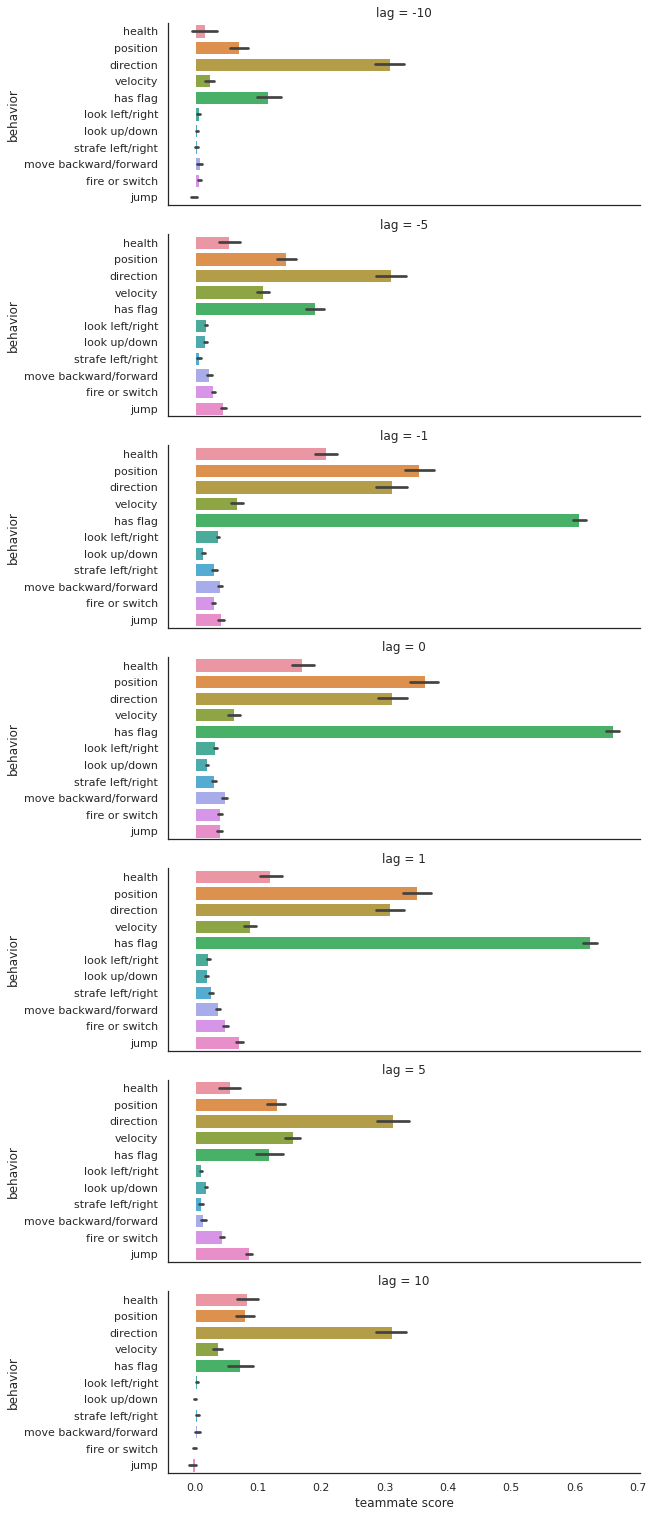

In [9]:
scores_df = pd.read_csv(f'results/behav-reg-r_opp-both_matchup-{matchup_id}_results.csv')
sns.catplot(y='behavior', x='teammate score', data=scores_df, kind='bar', row='lag', height=3, aspect=3);

In [10]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_width, teammate_width, opponent_width = 30, 30, 60

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'joint score': [], 'player score': [],
              'teammate score': [], 'opponent score': [],
              'lag': [], 'test map': [], 'PC': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms_in = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                              f'matchup-{matchup_id}_map-{test_map}.npy',
                              mode='r', dtype='float64', shape=train_shape)[
                                  train_repeats == repeat_id, :n_pcs]
    test_lstms_in = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                              f'matchup-{matchup_id}_map-{test_map}.npy',
                              mode='r', dtype='float64', shape=test_shape)[
                                  test_repeats == repeat_id, :n_pcs]

    stack_train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms_in, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    stack_test_lstms = np.stack(np.split(
        test_lstms_in, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):
        for lag in lags.keys():
            
            train_behav = stack_behav[train_maps, player_id]
            test_behav = stack_behav[test_map, player_id]
            train_lstms = stack_train_lstms[:, player_id]
            test_lstms = stack_test_lstms[player_id]

            (train_behav, test_behav,
             train_lstms, test_lstms) = apply_lag(train_behav, test_behav,
                                                  train_lstms, test_lstms,
                                                  lag=lag)
        
            train_behav = train_behav.reshape((-1, train_behav.shape[-1]))
            test_behav = test_behav.reshape((-1, test_behav.shape[-1]))
            train_lstms = train_lstms.reshape((-1, train_lstms.shape[-1]))
            test_lstms = test_lstms.reshape((-1, test_lstms.shape[-1]))
        
            scores = behavior_encoding(train_behav, test_behav,
                                       train_lstms, test_lstms,
                                       scorer=pearsonr)
            (joint_scores, player_scores,
             teammate_scores, opponent_scores) = scores
            lag_scores['joint score'].extend(joint_scores)
            lag_scores['player score'].extend(player_scores)
            lag_scores['teammate score'].extend(teammate_scores)
            lag_scores['opponent score'].extend(opponent_scores)
            lag_scores['lag'].extend([lags[lag]] * n_pcs)
            lag_scores['test map'].extend([test_map] * n_pcs)
            lag_scores['PC'].extend(np.arange(n_pcs))
            lag_scores['player'].extend([player_id] * n_pcs)
            for l, ss in zip(['joint', 'player', 'teammate', 'opponent'],
                             [joint_scores, player_scores,
                              teammate_scores, opponent_scores]):
                print(f"player {player_id} lag {lag} "
                      f"{l} r = {[f'{s:.2f}' for s in ss[:8]]} "
                      f"(test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/encoding-behav_opp-both_lags-all_matchup-{matchup_id}_results.csv', index=False)

/mnt/cup/labs/hasson/snastase/social-ctf/coupling_metrics.py:261: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  W, _, _, _ = lstsq(train_behav, train_lstms)


player 0 lag 150 joint r = ['-0.16', '0.04', '0.00', '0.13', '0.08', '0.13', '0.01', '0.07'] (test map 0)
player 0 lag 150 player r = ['-0.10', '0.05', '0.04', '0.04', '0.14', '-0.05', '-0.03', '0.04'] (test map 0)
player 0 lag 150 teammate r = ['-0.01', '-0.13', '0.01', '-0.00', '0.02', '0.12', '-0.10', '0.10'] (test map 0)
player 0 lag 150 opponent r = ['-0.13', '0.07', '-0.04', '0.15', '-0.06', '0.09', '0.11', '-0.06'] (test map 0)
player 0 lag 75 joint r = ['0.12', '0.14', '0.14', '0.23', '0.23', '0.16', '0.02', '0.14'] (test map 0)
player 0 lag 75 player r = ['0.13', '0.14', '0.14', '0.15', '0.20', '-0.02', '-0.02', '0.14'] (test map 0)
player 0 lag 75 teammate r = ['-0.00', '0.04', '-0.04', '0.17', '0.17', '0.15', '-0.01', '0.13'] (test map 0)
player 0 lag 75 opponent r = ['-0.01', '0.03', '0.06', '0.08', '-0.01', '0.13', '0.05', '-0.05'] (test map 0)
player 0 lag 15 joint r = ['0.58', '0.35', '0.47', '0.35', '0.73', '0.30', '0.59', '0.24'] (test map 0)
player 0 lag 15 player r =

In [12]:
scores_df = pd.read_csv(f'results/encoding-behav_opp-both_lags-all_matchup-{matchup_id}_results.csv')

In [13]:
behav_values = ['joint score', 'player score',
                'teammate score', 'opponent score']
scores_melt = scores_df.melt(
    id_vars=['lag', 'test map', 'PC', 'player'],
    value_vars=behav_values, var_name='behavior',
    value_name='score')
rename_behav = {b:b.split(' ')[0] for b in behav_values}
rename_behav['player score'] = 'own'
scores_melt.replace(to_replace=rename_behav, inplace=True)

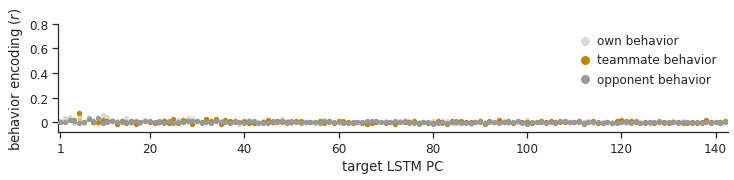

In [62]:
n_pcs = 142
lag = 10
palette = ['.85', 'darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.1)
bar_width = 1
#fig, ax = plt.subplots(figsize=(20, 4))
#fig, ax = plt.subplots(figsize=(12, 2.7))
fig, ax = plt.subplots(figsize=(12, 2))
sns.barplot(x='PC', y='score', estimator=fisher_mean,
            data=scores_melt[(scores_melt['lag'] == lag) &
                             (scores_melt['behavior'] == 'own')],
            ci=None, color='.95', zorder=0,
            capsize=0, ax=ax)
sns.barplot(x='PC', y='score', estimator=fisher_mean,
            data=scores_melt[(scores_melt['lag'] == lag) &
                             (scores_melt['behavior'] == 'teammate')],
            ci=None, color='xkcd:maize', zorder=0,
            capsize=0, ax=ax)
for patch in ax.patches:
    curr_width = patch.get_width()
    diff_width = curr_width - bar_width
    patch.set_width(bar_width)
    patch.set_x(patch.get_x() + diff_width * .5)
sns.pointplot(x='PC', y='score', hue='behavior', scale=.6, legend=False,
              data=scores_melt[(scores_melt['lag'] == lag) &
                               ((scores_melt['behavior'] == 'own') | 
                                (scores_melt['behavior'] == 'teammate') |
                                (scores_melt['behavior'] == 'opponent'))],
              join=False, ax=ax, errwidth=0, capsize=0,
              palette=sns.color_palette(palette, 3),
              estimator=fisher_mean)
ax.set(xlabel='target LSTM PC', ylabel='behavior encoding ($\it{r}$)', ylim=(-.08, .8))
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
ax.set_yticks([0, .2, .4, .6, .8])
ax.set_yticklabels([0, .2, .4, .6, .8])
handles, labels = ax.get_legend_handles_labels()
labels = ['own behavior', 'teammate behavior', 'opponent behavior']
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
l.legendHandles[0]._sizes = [60]
l.legendHandles[1]._sizes = [60]
l.legendHandles[2]._sizes = [60]
sns.despine()
plt.savefig(f'figures/encoding-behav_joint_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_width, teammate_width, opponent_width = 30, 30, 60

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'joint score': [], 'nested score': [],
              'lag': [], 'test map': [], 'PC': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms_in = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                              f'matchup-{matchup_id}_map-{test_map}.npy',
                              mode='r', dtype='float64', shape=train_shape)[
                                  train_repeats == repeat_id, :n_pcs]
    test_lstms_in = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                              f'matchup-{matchup_id}_map-{test_map}.npy',
                              mode='r', dtype='float64', shape=test_shape)[
                                  test_repeats == repeat_id, :n_pcs]

    stack_train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms_in, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    stack_test_lstms = np.stack(np.split(
        test_lstms_in, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):
        for lag in lags.keys():
            
            train_behav = stack_behav[train_maps, player_id]
            test_behav = stack_behav[test_map, player_id]
            train_lstms = stack_train_lstms[:, player_id]
            test_lstms = stack_test_lstms[player_id]

            (train_behav, test_behav,
             train_lstms, test_lstms) = apply_lag(train_behav, test_behav,
                                                  train_lstms, test_lstms,
                                                  lag=lag)
        
            train_behav = train_behav.reshape((-1, train_behav.shape[-1]))
            test_behav = test_behav.reshape((-1, test_behav.shape[-1]))
            train_lstms = train_lstms.reshape((-1, train_lstms.shape[-1]))
            test_lstms = test_lstms.reshape((-1, test_lstms.shape[-1]))

            scores = nested_encoding(train_behav, test_behav,
                                     train_lstms, test_lstms,
                                     opponent_width=opponent_width,
                                     scorer=r2_score)
            (joint_scores, nested_scores) = scores
            lag_scores['joint score'].extend(joint_scores)
            lag_scores['nested score'].extend(nested_scores)
            lag_scores['lag'].extend([lags[lag]] * n_pcs)
            lag_scores['test map'].extend([test_map] * n_pcs)
            lag_scores['PC'].extend(np.arange(n_pcs))
            lag_scores['player'].extend([player_id] * n_pcs)
            for l, ss in zip(['joint', 'nested'],
                          [joint_scores, nested_scores]):
                print(f"player {player_id} lag {lag} "
                      f"{l} r = {[f'{s:.2f}' for s in ss[:8]]} "
                      f"(test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/encoding-behav_nested_lags-all_matchup-{matchup_id}_results.csv', index=False)

player 0 lag 150 joint r = ['-0.03', '-0.00', '-0.01', '0.02', '-0.01', '0.02', '-0.02', '0.00'] (test map 0)
player 0 lag 150 nested r = ['-0.03', '0.01', '-0.01', '0.02', '0.01', '0.00', '-0.00', '-0.01'] (test map 0)
player 0 lag 75 joint r = ['0.01', '0.01', '0.01', '0.05', '0.03', '0.03', '-0.04', '0.01'] (test map 0)
player 0 lag 75 nested r = ['0.01', '0.00', '0.02', '0.04', '0.01', '0.01', '-0.03', '0.02'] (test map 0)
player 0 lag 15 joint r = ['0.34', '0.12', '0.21', '0.12', '0.52', '0.09', '0.32', '0.05'] (test map 0)
player 0 lag 15 nested r = ['0.33', '0.11', '0.19', '0.09', '0.48', '0.08', '0.25', '0.03'] (test map 0)
player 0 lag 0 joint r = ['0.66', '0.26', '0.18', '0.14', '0.60', '0.21', '0.43', '0.13'] (test map 0)
player 0 lag 0 nested r = ['0.65', '0.24', '0.18', '0.13', '0.56', '0.19', '0.37', '0.11'] (test map 0)
player 0 lag -15 joint r = ['0.17', '0.11', '0.08', '0.07', '0.42', '0.08', '0.25', '0.04'] (test map 0)
player 0 lag -15 nested r = ['0.17', '0.10', '0.

/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/ipykernel_launcher.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  app.launch_new_instance()


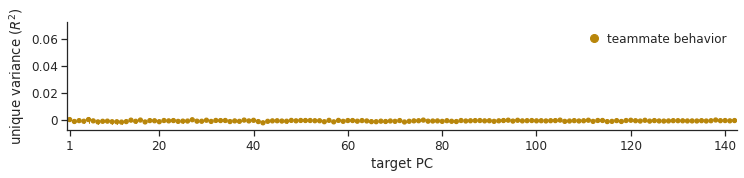

In [77]:
from matplotlib.lines import Line2D

scores_df = pd.read_csv(f'results/encoding-behav_nested_lags-all_matchup-{matchup_id}_results.csv')

scores_df['unique'] = ((scores_df['joint score'] - 
                        scores_df['nested score']))

lag = 10
bar_width = 1

sns.set(style='ticks', font_scale=1.1)
#fig, ax = plt.subplots(figsize=(20, 4))
#fig, ax = plt.subplots(figsize=(12, 2.5))
fig, ax = plt.subplots(figsize=(12, 2))
sns.barplot(x='PC', y='unique',
            data=scores_df[scores_melt['lag'] == lag],
            ci=None, color='.9', zorder=0,
            capsize=0, ax=ax)
for patch in ax.patches:
    curr_width = patch.get_width()
    diff_width = curr_width - bar_width
    patch.set_width(bar_width)
    patch.set_x(patch.get_x() + diff_width * .5)
sns.pointplot(x='PC', y='unique', errwidth=1,
              data=scores_df[scores_df['lag'] == lag],
              join=False, ax=ax, scale=.6, color='darkgoldenrod',
              legend='full')
ax.set(xlabel='target PC', ylabel='unique variance ($\it{R}^2$)',
       ylim=(-.008, .073))
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
ax.set_yticks([0, .02, .04, .06])
ax.set_yticklabels([0, .02, .04, .06])
#handles, labels = ax.get_legend_handles_labels()
handles = [Line2D([0], [0], marker='o', markersize=8,
                  linestyle='', color='darkgoldenrod')]
labels = ['teammate behavior']
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
#l.legendHandles[0]._sizes = [200]
sns.despine()
plt.savefig(f'figures/encoding-behav_unique_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

In [29]:
# Load up and stack behaviors for player, teammate, and opponent
# Re-stack behaviors to isolate unique opponent variance
n_players = 4
map_id, matchup_id, repeat_id = slice(None), 0, 0

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

stack_behav = []
for player_id in np.arange(n_players):
    player_behav = stack_behaviors(
        player_id, map_id=map_id,
        matchup_id=matchup_id, repeat_id=repeat_id)
    print(f"Player behavior shape: {player_behav.shape}")
    
    teammate_behav = stack_behaviors(
        player_teammate[player_id], map_id=map_id,
        matchup_id=matchup_id, repeat_id=repeat_id)
    print(f"Teammate behavior shape: {teammate_behav.shape}")

    opponent_behav = []
    for opp_id in player_opponents[player_id]:
        opponent_behav.append(stack_behaviors(
            opp_id, map_id=map_id,
            matchup_id=matchup_id, repeat_id=repeat_id))
    opponent_behav = np.concatenate(opponent_behav, axis=-1)
    print(f"Opponent behavior shape: {opponent_behav.shape}")
    
    stack_behav.append(np.concatenate((player_behav,
                                       opponent_behav,
                                       teammate_behav), axis=-1))

stack_behav_opp = np.stack(stack_behav, -3)
print(f"Stacked behavior shape: {stack_behav_opp.shape}")

Player behavior shape: (32, 4501, 30)
Teammate behavior shape: (32, 4501, 30)
Opponent behavior shape: (32, 4501, 60)
Player behavior shape: (32, 4501, 30)
Teammate behavior shape: (32, 4501, 30)
Opponent behavior shape: (32, 4501, 60)
Player behavior shape: (32, 4501, 30)
Teammate behavior shape: (32, 4501, 30)
Opponent behavior shape: (32, 4501, 60)
Player behavior shape: (32, 4501, 30)
Teammate behavior shape: (32, 4501, 30)
Opponent behavior shape: (32, 4501, 60)
Stacked behavior shape: (32, 4, 4501, 120)


In [ ]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_width, teammate_width, opponent_width = 30, 30, 60

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'joint score': [], 'nested score': [],
              'lag': [], 'test map': [], 'PC': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms_in = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                              f'matchup-{matchup_id}_map-{test_map}.npy',
                              mode='r', dtype='float64', shape=train_shape)[
                                  train_repeats == repeat_id, :n_pcs]
    test_lstms_in = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                              f'matchup-{matchup_id}_map-{test_map}.npy',
                              mode='r', dtype='float64', shape=test_shape)[
                                  test_repeats == repeat_id, :n_pcs]

    stack_train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms_in, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    stack_test_lstms = np.stack(np.split(
        test_lstms_in, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):
        for lag in lags.keys():
            
            train_behav = stack_behav_opp[train_maps, player_id]
            test_behav = stack_behav_opp[test_map, player_id]
            train_lstms = stack_train_lstms[:, player_id]
            test_lstms = stack_test_lstms[player_id]

            (train_behav, test_behav,
             train_lstms, test_lstms) = apply_lag(train_behav, test_behav,
                                                  train_lstms, test_lstms,
                                                  lag=lag)
        
            train_behav = train_behav.reshape((-1, train_behav.shape[-1]))
            test_behav = test_behav.reshape((-1, test_behav.shape[-1]))
            train_lstms = train_lstms.reshape((-1, train_lstms.shape[-1]))
            test_lstms = test_lstms.reshape((-1, test_lstms.shape[-1]))

            scores = nested_encoding(train_behav, test_behav,
                                     train_lstms, test_lstms,
                                     teammate_width=opponent_width,
                                     opponent_width=teammate_width,
                                     scorer=r2_score)
            (joint_scores, nested_scores) = scores
            lag_scores['joint score'].extend(joint_scores)
            lag_scores['nested score'].extend(nested_scores)
            lag_scores['lag'].extend([lags[lag]] * n_pcs)
            lag_scores['test map'].extend([test_map] * n_pcs)
            lag_scores['PC'].extend(np.arange(n_pcs))
            lag_scores['player'].extend([player_id] * n_pcs)
            for l, ss in zip(['joint', 'nested'],
                          [joint_scores, nested_scores]):
                print(f"player {player_id} lag {lag} "
                      f"{l} r = {[f'{s:.2f}' for s in ss[:8]]} "
                      f"(test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/encoding-behav_nestedopp_lags-all_matchup-{matchup_id}_results.csv', index=False)

player 0 lag 150 joint r = ['-0.03', '-0.00', '-0.01', '0.02', '-0.01', '0.02', '-0.02', '0.00'] (test map 0)
player 0 lag 150 nested r = ['-0.02', '-0.01', '0.00', '-0.00', '0.00', '0.01', '-0.03', '0.01'] (test map 0)
player 0 lag 75 joint r = ['0.01', '0.01', '0.01', '0.05', '0.03', '0.03', '-0.04', '0.01'] (test map 0)
player 0 lag 75 nested r = ['0.02', '0.01', '0.01', '0.04', '0.04', '0.01', '-0.03', '0.02'] (test map 0)
player 0 lag 15 joint r = ['0.34', '0.12', '0.21', '0.12', '0.52', '0.09', '0.32', '0.05'] (test map 0)
player 0 lag 15 nested r = ['0.33', '0.09', '0.10', '0.06', '0.51', '0.08', '0.17', '0.06'] (test map 0)
player 0 lag 0 joint r = ['0.66', '0.26', '0.18', '0.14', '0.60', '0.21', '0.43', '0.13'] (test map 0)
player 0 lag 0 nested r = ['0.65', '0.23', '0.12', '0.08', '0.58', '0.20', '0.21', '0.13'] (test map 0)
player 0 lag -15 joint r = ['0.17', '0.11', '0.08', '0.07', '0.42', '0.08', '0.25', '0.04'] (test map 0)
player 0 lag -15 nested r = ['0.18', '0.09', '0.

/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/ipykernel_launcher.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  from ipykernel import kernelapp as app


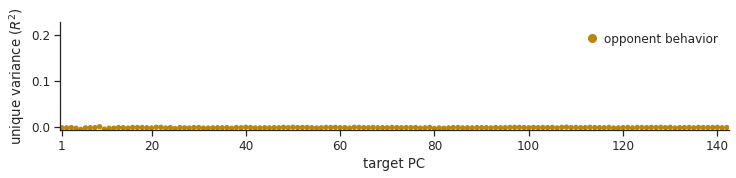

In [51]:
from matplotlib.lines import Line2D

scores_df = pd.read_csv(f'results/encoding-behav_nestedopp_lags-all_matchup-{matchup_id}_results.csv')

scores_df['unique'] = ((scores_df['joint score'] - 
                        scores_df['nested score']))

lag = 10
bar_width = 1

sns.set(style='ticks', font_scale=1.1)
#fig, ax = plt.subplots(figsize=(20, 4))
fig, ax = plt.subplots(figsize=(12, 2))
sns.barplot(x='PC', y='unique',
            data=scores_df[scores_melt['lag'] == lag],
            ci=None, color='.9', zorder=0,
            capsize=0, ax=ax)
for patch in ax.patches:
    curr_width = patch.get_width()
    diff_width = curr_width - bar_width
    patch.set_width(bar_width)
    patch.set_x(patch.get_x() + diff_width * .5)
sns.pointplot(x='PC', y='unique', errwidth=1,
              data=scores_df[scores_df['lag'] == lag],
              join=False, ax=ax, scale=.6, color='darkgoldenrod',
              legend='full')
ax.set(xlabel='target PC', ylabel='unique variance ($\it{R}^2$)',
       ylim=(-.008, .23))
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
#handles, labels = ax.get_legend_handles_labels()
handles = [Line2D([0], [0], marker='o', markersize=8,
                  linestyle='', color='darkgoldenrod')]
labels = ['opponent behavior']
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
#l.legendHandles[0]._sizes = [200]
sns.despine()
plt.savefig(f'figures/encoding-behav_uniqueopp_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)